# Etapa 3 — Reto *Nuevo dataset*: detección en imágenes aéreas (VisDrone) con YOLO y diseño factorial
**Curso:** Visión por Computador Avanzada (PCJIC, 2026-2) · **Autor:** Milton Alvarado

**Dataset:** VisDrone2019-DET (imágenes de dron, 10 clases: peatón, persona, bicicleta, auto, van, camión, triciclo, triciclo con toldo, bus, moto).
**Requisito (3b):** ≥ 3 modelos o 3 ajustes de hiperparámetros con análisis comparativo. **(3c):** análisis riguroso con fundamentos matemáticos.

## Enfoque ligado a la tesis
Un dron es una plataforma móvil con cámara: sus imágenes tienen objetos diminutos, movimiento y textura variable, condiciones análogas a las de VI-SLAM.
En lugar de probar 3 configuraciones ad hoc (OFAT), se aplica en pequeño la metodología de la propuesta:

| Elemento de la tesis | Aquí |
|---|---|
| Diseño factorial 2² | factores **A = tamaño de modelo** (YOLOv8n vs YOLOv8s) y **B = resolución de entrada** (`imgsz` 512 vs 800) → 4 corridas |
| Modelo de efectos / RSM | $Y=\beta_0+\beta_A x_A+\beta_B x_B+\beta_{AB}x_Ax_B$ con factores codificados $\pm1$ |
| Respuestas | mAP50 (precisión), latencia por imagen (eficiencia), recall en objetos pequeños (robustez) |
| Trade-off | **Función de deseabilidad de Derringer–Suich** sobre mAP y latencia |

*Nota estadística:* un 2² con una sola réplica es saturado (4 corridas, 4 coeficientes): los efectos se estiman pero no hay grados de libertad para su significancia.
Con más tiempo de GPU, usar `SEEDS = [0, 1, 2]` para obtener error puro y un ANOVA.

## 0. Entorno y datos

In [1]:
!pip -q install ultralytics pycocotools
import os, time, glob, itertools, random, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt, cv2, torch
from pathlib import Path
warnings.filterwarnings("ignore")
from ultralytics import YOLO
print(torch.__version__, torch.cuda.is_available())

SEEDS  = [0]                 # recomendado: [0,1,2] para ANOVA
EPOCHS = 30                  # 30 es un compromiso; 60+ para resultados finales
FRACTION = 1.0               # <1.0 (p.ej. 0.3) para pruebas rápidas
BATCH  = 64

2.11.0+cu128 True


VisDrone se descarga automáticamente con `data="VisDrone.yaml"` (~2 GB). Las imágenes tienen ~2000×1500 px, así que la resolución de entrada
(`imgsz`) reduce mucho los objetos: un peatón de 20 px a `imgsz=512` queda de ~5 px. Esto motiva el factor B.

## 1. Diseño experimental
Codificación: $x=-1$ (nivel bajo) y $x=+1$ (nivel alto). Orden de ejecución aleatorizado (principio de aleatorización de Fisher).

In [2]:
levels = {"A_model": {-1:"yolov8n.pt", +1:"yolov8s.pt"}, "B_imgsz": {-1:512, +1:800}}
design = pd.DataFrame(list(itertools.product([-1,1],[-1,1])), columns=["xA","xB"])
design["model"] = design.xA.map(levels["A_model"]); design["imgsz"] = design.xB.map(levels["B_imgsz"])
design = design.loc[np.repeat(design.index, len(SEEDS))].reset_index(drop=True)
design["seed"] = SEEDS * (len(design)//len(SEEDS))
design["run_id"] = [f"r{i}_{m.split('.')[0]}_{s}_s{sd}" for i,(m,s,sd) in enumerate(zip(design.model, design.imgsz, design.seed))]
design = design.sample(frac=1, random_state=42).reset_index(drop=True)   # aleatorización
design

,xA,xB,model,imgsz,seed,run_id
0,-1,1,yolov8n.pt,800,0,r1_yolov8n_800_s0
1,1,1,yolov8s.pt,800,0,r3_yolov8s_800_s0
2,-1,-1,yolov8n.pt,512,0,r0_yolov8n_512_s0
3,1,-1,yolov8s.pt,512,0,r2_yolov8s_512_s0


In [5]:
from google.colab import drive
drive.mount('/content/drive')
import os
from pathlib import Path
OUT = Path("/content/drive/MyDrive/PhD/2026_02/Vision_por_computador/Ejercicio 2/resultados/etapa3")
OUT.mkdir(parents=True, exist_ok=True)
os.chdir(OUT)
print("Resultados en:", OUT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Resultados en: /content/drive/MyDrive/PhD/2026_02/Vision_por_computador/Ejercicio 2/resultados/etapa3


## 2. Entrenamiento y evaluación

In [7]:
import shutil
from ultralytics.utils.torch_utils import get_flops
WDIR = OUT / "weights"; WDIR.mkdir(exist_ok=True)   # pesos best.pt copiados a Drive

def train_run(row):
    best_path = WDIR / f"{row.run_id}.pt"
    if not best_path.exists():                       # si ya se entrenó (p.ej. antes de un error), no repetir
        m = YOLO(row.model)
        m.train(data="VisDrone.yaml", epochs=EPOCHS, imgsz=int(row.imgsz), batch=BATCH, cache="ram", workers=8, seed=int(row.seed),
                fraction=FRACTION, project="runs_visdrone", name=row.run_id, exist_ok=True, plots=False, verbose=False, patience=10)
        shutil.copy(Path(m.trainer.save_dir) / "weights" / "best.pt", best_path)
    best = YOLO(str(best_path))
    v = best.val(data="VisDrone.yaml", imgsz=int(row.imgsz), batch=BATCH, plots=False, verbose=False)
    params = sum(p.numel() for p in best.model.parameters())
    try: gflops = get_flops(best.model, int(row.imgsz))
    except Exception: gflops = float("nan")
    out = dict(run_id=row.run_id, best_path=str(best_path), xA=row.xA, xB=row.xB, model=row.model, imgsz=row.imgsz, seed=row.seed,
               map50=v.box.map50, map5095=v.box.map, precision=v.box.mp, recall=v.box.mr,
               lat_ms=v.speed["inference"], total_ms=sum(v.speed.values()), params_M=params/1e6, gflops=gflops,
               per_class_ap50=dict(zip([best.names[i] for i in v.box.ap_class_index], v.box.ap50)))
    return out

results = pd.read_pickle("resultados_etapa3_raw.pkl").to_dict("records") if Path("resultados_etapa3_raw.pkl").exists() else []
done = {r["run_id"] for r in results}; print("Corridas ya terminadas:", sorted(done))
for _, row in design.iterrows():
    if row.run_id in done: continue
    t = time.time(); r = train_run(row); r["train_min"] = (time.time()-t)/60; results.append(r)
    print({k:(round(v,3) if isinstance(v,float) else v) for k,v in r.items() if k!="per_class_ap50"})
    pd.DataFrame(results).to_pickle("resultados_etapa3_raw.pkl")
R = pd.DataFrame(results); R.drop(columns="per_class_ap50")

Corridas ya terminadas: []
Ultralytics 8.4.166 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
Model summary (fused): 72 layers, 3,007,598 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 10340.7±3196.7 MB/s, size: 172.5 KB)
val: Scanning /content/datasets/VisDrone/labels/val.cache... 548 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 548/548 383.1Mit/s 0.0s
WARNING ⚠️ Dataset images contain up to 317 objects (val=317), but max_det=300. This mismatch can cap recall and produce invalid validation metrics. Raising it may increase validation cost but cannot increase model or export capacity, which may cap recall. Setting max_det=317 to match the observed maximum.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 4.5it/s 2.0s
                   all        548      38759      0.464      0.353       0.34      0.195
Speed: 0.2ms preprocess

,run_id,best_path,xA,xB,model,imgsz,seed,map50,map5095,precision,recall,lat_ms,total_ms,params_M,gflops,train_min
0,r1_yolov8n_800_s0,/content/drive/MyDrive/PhD/2026_02/Vision_por_...,-1,1,yolov8n.pt,800,0,0.340066,0.195175,0.464389,0.352758,0.331898,1.476630,3.012798,12.814640,0.039496
1,r3_yolov8s_800_s0,/content/drive/MyDrive/PhD/2026_02/Vision_por_...,1,1,yolov8s.pt,800,0,0.427779,0.253370,0.555271,0.427750,0.761574,1.680179,11.139470,44.783440,8.656912
2,r0_yolov8n_512_s0,/content/drive/MyDrive/PhD/2026_02/Vision_por_...,-1,-1,yolov8n.pt,512,0,0.228724,0.124514,0.365376,0.259863,0.191555,1.051908,3.012798,5.248877,3.125642
3,r2_yolov8s_512_s0,/content/drive/MyDrive/PhD/2026_02/Vision_por_...,1,-1,yolov8s.pt,512,0,0.306387,0.172697,0.459193,0.323406,0.332957,1.068119,11.139470,18.343297,4.236977


## 3. Robustez por tamaño de objeto (recall de objetos pequeños)
Se empareja predicción–verdad de terreno con IoU ≥ 0.5 y misma clase, y se calcula el recall por bucket de área en píxeles de la imagen original
(estilo COCO): *small* < 32², *medium* 32²–96², *large* > 96². Recuerda $\text{Recall}=TP/(TP+FN)$.

In [9]:
VAL_IMG = sorted(glob.glob("/content/datasets/VisDrone/images/val/*.jpg"))
print(len(VAL_IMG), "imágenes de validación")

def iou_xyxy(a, b):
    x1=np.maximum(a[:,None,0],b[None,:,0]); y1=np.maximum(a[:,None,1],b[None,:,1])
    x2=np.minimum(a[:,None,2],b[None,:,2]); y2=np.minimum(a[:,None,3],b[None,:,3])
    inter=np.clip(x2-x1,0,None)*np.clip(y2-y1,0,None)
    A=(a[:,2]-a[:,0])*(a[:,3]-a[:,1]); B=(b[:,2]-b[:,0])*(b[:,3]-b[:,1])
    return inter/(A[:,None]+B[None,:]-inter+1e-9)

def bucket(area): return "small" if area < 32**2 else ("medium" if area < 96**2 else "large")

def recall_by_size(weights, imgsz, files, n=300, conf=0.25):
    model = YOLO(weights); tp = {"small":0,"medium":0,"large":0}; tot = dict(tp)
    for f in files[:n]:
        lab = Path(f.replace("/images/","/labels/")).with_suffix(".txt")
        if not lab.exists(): continue
        L = np.loadtxt(lab, ndmin=2)
        if L.size == 0: continue
        h, w = cv2.imread(f).shape[:2]
        gt = np.c_[(L[:,1]-L[:,3]/2)*w, (L[:,2]-L[:,4]/2)*h, (L[:,1]+L[:,3]/2)*w, (L[:,2]+L[:,4]/2)*h]; gc = L[:,0].astype(int)
        r = model.predict(f, imgsz=imgsz, conf=conf, max_det=1000, verbose=False)[0]
        pb = r.boxes.xyxy.cpu().numpy(); pc = r.boxes.cls.cpu().numpy().astype(int)
        I = iou_xyxy(gt, pb) if len(pb) else np.zeros((len(gt),0))
        for i in range(len(gt)):
            b = bucket((gt[i,2]-gt[i,0])*(gt[i,3]-gt[i,1])); tot[b]+=1
            if I.shape[1] and ((I[i]>=0.5) & (pc==gc[i])).any(): tp[b]+=1
    return {f"recall_{b}": tp[b]/max(tot[b],1) for b in tot} | {f"n_{b}": tot[b] for b in tot}

rec = [recall_by_size(r.best_path, int(r.imgsz), VAL_IMG) for r in R.itertuples()]
R = pd.concat([R.reset_index(drop=True), pd.DataFrame(rec)], axis=1)
R[["run_id","map50","lat_ms","recall_small","recall_medium","recall_large"]]

548 imágenes de validación


,run_id,map50,lat_ms,recall_small,recall_medium,recall_large
0,r1_yolov8n_800_s0,0.340066,0.331898,0.363719,0.726044,0.869565
1,r3_yolov8s_800_s0,0.427779,0.761574,0.452385,0.783374,0.907115
2,r0_yolov8n_512_s0,0.228724,0.191555,0.225023,0.631450,0.837945
3,r2_yolov8s_512_s0,0.306387,0.332957,0.306973,0.700860,0.879447


## 4. Análisis factorial de efectos
Para el factorial $2^2$ con codificación $\pm1$ el efecto de un factor es $E_A=\bar y_{A+}-\bar y_{A-}$ y $\beta_A=E_A/2$; la interacción
$E_{AB}=\tfrac12\big[(y_{++}-y_{-+})-(y_{+-}-y_{--})\big]$. Una interacción grande indica que el efecto del tamaño de modelo **depende** de la resolución (algo que un
diseño OFAT no puede ver).

,media,E_modelo,E_imgsz,E_interaccion
map50,0.3257,0.0827,0.1164,0.0050
map5095,0.1864,0.0532,0.0757,0.0050
lat_ms,0.4045,0.2855,0.2845,0.1441
recall_small,0.3370,0.0853,0.1421,0.0034


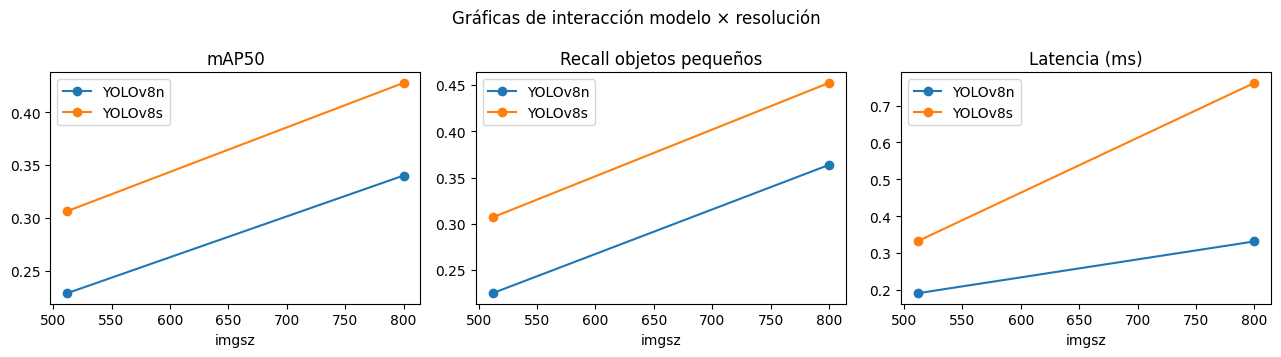

In [10]:
def effects(df, y):
    g = df.groupby(["xA","xB"])[y].mean()
    yA  = (g.loc[(1,-1)]+g.loc[(1,1)])/2 - (g.loc[(-1,-1)]+g.loc[(-1,1)])/2
    yB  = (g.loc[(-1,1)]+g.loc[(1,1)])/2 - (g.loc[(-1,-1)]+g.loc[(1,-1)])/2
    yAB = ((g.loc[(1,1)]-g.loc[(-1,1)]) - (g.loc[(1,-1)]-g.loc[(-1,-1)]))/2
    return dict(media=g.mean(), E_modelo=yA, E_imgsz=yB, E_interaccion=yAB)
ef = pd.DataFrame({y: effects(R, y) for y in ["map50","map5095","lat_ms","recall_small"]}).T
display(ef.round(4)); ef.to_csv("efectos_etapa3.csv")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for a, y, t in zip(ax, ["map50","recall_small","lat_ms"], ["mAP50","Recall objetos pequeños","Latencia (ms)"]):
    for xa, lab in ((-1,"YOLOv8n"),(1,"YOLOv8s")):
        s = R[R.xA==xa].groupby("imgsz")[y].mean(); a.plot(s.index, s.values, "o-", label=lab)
    a.set_title(t); a.set_xlabel("imgsz"); a.legend()
plt.suptitle("Gráficas de interacción modelo × resolución"); plt.tight_layout(); plt.savefig("interaccion_etapa3.png", dpi=200); plt.show()

## 5. Trade-off multiobjetivo: función de deseabilidad (Derringer–Suich)
Como en la propuesta, cada respuesta se transforma a $d_i\in[0,1]$ y se combina como media geométrica ponderada
$D=\big(\prod d_i^{w_i}\big)^{1/\sum w_i}$.
* Maximizar mAP50: $d=\big(\tfrac{Y-L}{T-L}\big)^r$ para $L<Y<T$; 0 si $Y\le L$; 1 si $Y\ge T$.
* Minimizar latencia: $d=\big(\tfrac{U-Y}{U-T}\big)^r$ para $T<Y<U$; 1 si $Y\le T$; 0 si $Y\ge U$.

Los límites ($L,T,U$) representan el requisito de la aplicación (p. ej., dron con cómputo embebido). **Se deben justificar en el informe.**

In [11]:
def d_max(y, L, T, r=1): return np.clip((y-L)/(T-L), 0, 1)**r
def d_min(y, T, U, r=1): return np.clip((U-y)/(U-T), 0, 1)**r
def desirability(df, w=(2,1,1), map_LT=(0.15,0.40), lat_TU=(8,40), rec_LT=(0.05,0.35)):
    d1 = d_max(df.map50, *map_LT); d2 = d_min(df.lat_ms, *lat_TU); d3 = d_max(df.recall_small, *rec_LT)
    return (d1**w[0] * d2**w[1] * d3**w[2]) ** (1/sum(w))
R["D"] = desirability(R)
S = R.groupby(["model","imgsz"], as_index=False)[["map50","lat_ms","recall_small","D"]].mean().sort_values("D", ascending=False); display(S.round(3))

# sensibilidad a los pesos: ¿cambia la configuración óptima?
for w in [(1,1,1),(2,1,1),(1,2,1),(1,1,2),(3,1,1)]:
    Dw = desirability(R, w=w); print(w, "->", R.loc[Dw.idxmax(), "run_id"])

,model,imgsz,map50,lat_ms,recall_small,D
3,yolov8s.pt,800,0.428,0.762,0.452,1.000
1,yolov8n.pt,800,0.340,0.332,0.364,0.872
2,yolov8s.pt,512,0.306,0.333,0.307,0.761
0,yolov8n.pt,512,0.229,0.192,0.225,0.490


(1, 1, 1) -> r3_yolov8s_800_s0
(2, 1, 1) -> r3_yolov8s_800_s0
(1, 2, 1) -> r3_yolov8s_800_s0
(1, 1, 2) -> r3_yolov8s_800_s0
(3, 1, 1) -> r3_yolov8s_800_s0


## 6. Resumen y análisis por clase

,r1_yolov8n_800_s0,r3_yolov8s_800_s0,r0_yolov8n_512_s0,r2_yolov8s_512_s0
pedestrian,0.379,0.491,0.214,0.315
people,0.284,0.363,0.172,0.237
bicycle,0.096,0.177,0.024,0.073
car,0.765,0.812,0.648,0.718
van,0.392,0.467,0.254,0.348
truck,0.302,0.399,0.220,0.299
tricycle,0.223,0.323,0.133,0.198
awning-tricycle,0.119,0.162,0.058,0.104
bus,0.450,0.574,0.337,0.434
motor,0.391,0.509,0.226,0.337


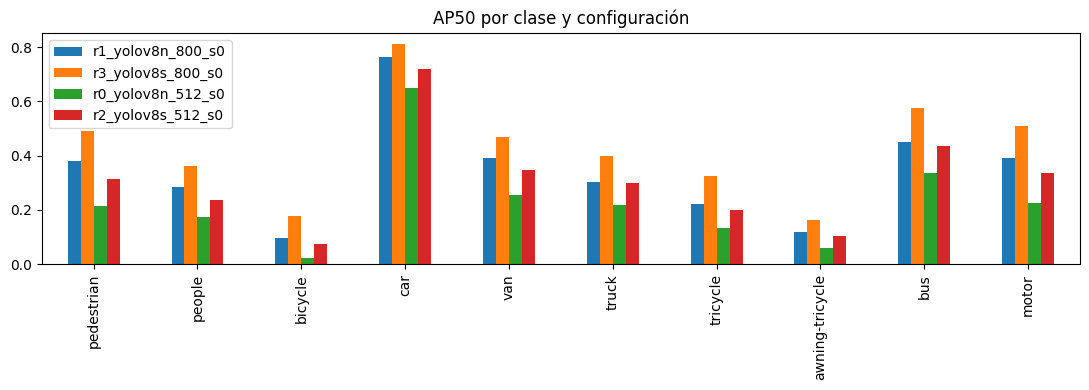

In [12]:
final = R.drop(columns=[c for c in R.columns if c=="per_class_ap50"]); final.to_csv("resultados_etapa3.csv", index=False)
pc = pd.DataFrame([r["per_class_ap50"] for r in results], index=[r["run_id"] for r in results]).T
display(pc.round(3))
pc.plot.bar(figsize=(11,4), title="AP50 por clase y configuración"); plt.tight_layout(); plt.savefig("ap_por_clase_etapa3.png", dpi=200); plt.show()

### Guía para redactar el análisis (completar con tus cifras)
1. **Escala y resolución:** un objeto de $s$ px en la imagen original mide $s\cdot \text{imgsz}/W$ tras el *resize*; con $W\approx2000$ e `imgsz=512`, un peatón de 20 px queda en ~5 px, menor que el *stride* mínimo (8) de las cabezas de detección: se pierde información. Contrastar con `recall_small`.
2. **Capacidad vs. datos:** YOLOv8s ($\approx$11 M parámetros) vs n ($\approx$3 M): discutir mAP ganado por milisegundo perdido (coste marginal).
3. **Interacción A×B:** interpretar $E_{AB}$; si es grande, el beneficio de un modelo mayor depende de la resolución y una selección OFAT sería engañosa.
4. **Función de deseabilidad:** reportar $D$ y su sensibilidad a los pesos; conectar con la Fase 2 de la tesis (validación multiobjetivo mAP–latencia ↔ ATE–TFR).
5. **Clases confundibles:** *pedestrian/people*, *tricycle/awning-tricycle*, *van/car* — analizar `AP50` por clase y desequilibrio de clases (pérdida de clasificación y *focal/BCE*).
6. **Limitaciones:** una semilla, 30 épocas, sin réplicas; los efectos son descriptivos y no inferenciales hasta usar `SEEDS=[0,1,2]`.